# 1 ACP, clustering

Dans cette partie, vous allez implémenter l’ACP (centrée et réduite) et créer tous les indicateurs
nécessaires pour réaliser une interprétation de l’ACP. 

Utiliser la fonction PCA() et ses sorties (voir le TP sur le
clustering) pour :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.interpolate import BSpline

In [2]:
data = pd.read_csv("lidar.txt", delim_whitespace=True)

À l'aide de la fonction PCA(), nous donnons la représentation des individus dans le premier plan et l'on ajoute le porucentage de variance expliquée sur les composantes.

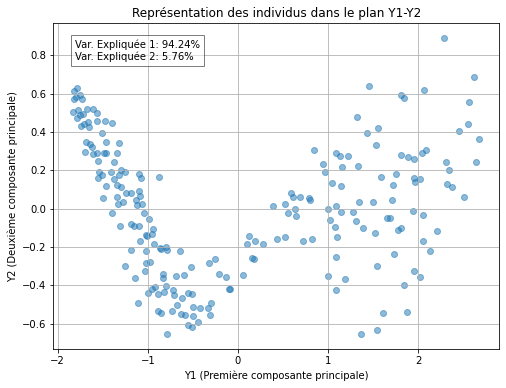

In [3]:
pca = PCA()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
pca.fit(data_scaled)

components = pca.transform(data_scaled)

Y1 = components[:, 0]
Y2 = components[:, 1]

# le pourcentage de variance expliquée par chaque composante
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
plt.scatter(Y1, Y2, alpha=0.5)
plt.title("Représentation des individus dans le plan Y1-Y2")
plt.xlabel("Y1 (Première composante principale)")
plt.ylabel("Y2 (Deuxième composante principale)")
plt.grid(True)

box_text = '\n'.join([f"Var. Expliquée {i+1}: {ratio:.2%}" for i, ratio in enumerate(explained_variance_ratio)])
plt.text(0.05, 0.95, box_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.show()

2 - La représentation des variables

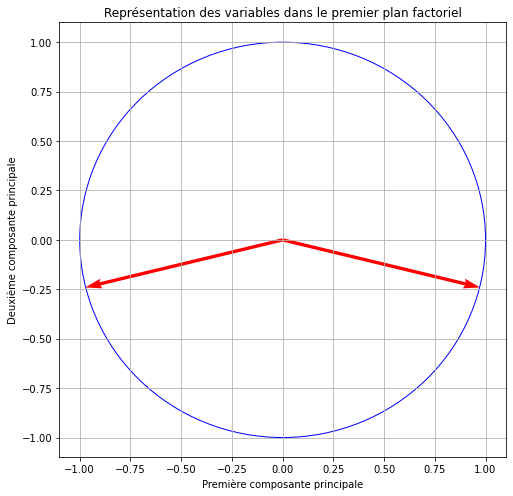

In [4]:
correlation_circle = np.sqrt(pca.explained_variance_)[:, np.newaxis] * pca.components_

circle = plt.Circle((0,0), 1, color='blue', fill=False)

plt.figure(figsize=(8, 8))
plt.gca().add_artist(circle)
plt.quiver(np.zeros(correlation_circle.shape[1]), np.zeros(correlation_circle.shape[1]),
           correlation_circle[0, :], correlation_circle[1, :],
           angles='xy', scale_units='xy', scale=1, color='red')
plt.title("Représentation des variables dans le premier plan factoriel")
plt.xlabel("Première composante principale")
plt.ylabel("Deuxième composante principale")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.show()

3- Après les calculs de contribution et de représentation, j'ai repris les questions précédentes car les données n'étaient pas centrées ni réduites. C'est une étape importante car les fonctionnalités ne le font pas tout seul contrairement à R.

In [5]:
contributions = np.square(components) / (len(components)*pca.explained_variance_)

representation_quality = np.square(components) / np.sum(np.square(components), axis=1)[:, np.newaxis]

for i in range(2):
    print(f"Individu {i+1}:")
    print(f" - Contribution sur l'axe 1: {contributions[i, 0]:.2%}")
    print(f" - Contribution sur l'axe 2: {contributions[i, 1]:.2%}")
    print(f" - Qualité de la représentation sur l'axe 1: {representation_quality[i, 0]:.2%}")
    print(f" - Qualité de la représentation sur l'axe 2: {representation_quality[i, 1]:.2%}")


Individu 1:
 - Contribution sur l'axe 1: 0.79%
 - Contribution sur l'axe 2: 1.47%
 - Qualité de la représentation sur l'axe 1: 89.82%
 - Qualité de la représentation sur l'axe 2: 10.18%
Individu 2:
 - Contribution sur l'axe 1: 0.77%
 - Contribution sur l'axe 2: 1.55%
 - Qualité de la représentation sur l'axe 1: 88.97%
 - Qualité de la représentation sur l'axe 2: 11.03%


4 - c'est ok par rapport aux valeurs de R à quelques arrondis près mais ça vient du fait que les valeurs propres ne sont pas tout à fait les mêmes.

In [6]:
from ISLP import load_data
nci60_data = load_data('NCI60')

Partie 2

J'ai du remanipulé le dataset car c'est un dictionnaire donc toutes les fonctions de Kmeans ne pouvaient pas fonctionner dessus. Ensuite on combine ACP et clustering.

In [7]:
data_array = nci60_data['data']
labels_array = nci60_data['labels']

# On crée le DataFrame pour les données
nci60_df = pd.DataFrame(data_array)

nci60_df['label'] = labels_array.values

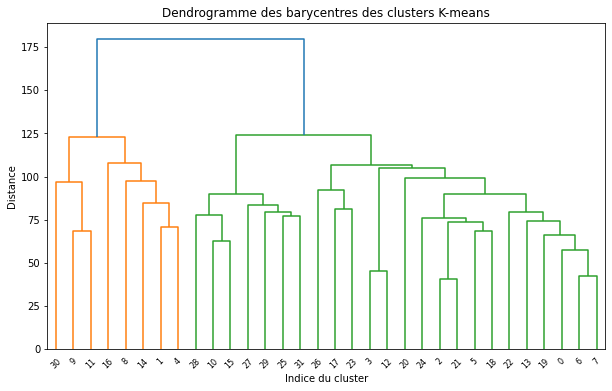

In [8]:
#On applique K-means avec n/2 classes donc ici 32
kmeans = KMeans(n_clusters=32, random_state=11052000, n_init=10)
kmeans.fit(data_array)
labels = kmeans.labels_
centre = kmeans.cluster_centers_

# On applique la CAH sur les barycentres
Z = linkage(centre, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrogramme des barycentres des clusters K-means')
plt.xlabel('Indice du cluster')
plt.ylabel('Distance')
plt.show()

Donc on a ici beaucoup de classes, chacune de deux éléments. Grâce au dendogramme on peut voir le nombre de KMeans que l'on préfère.

# 2 Régression non-paramétrique par des fonctions à noyau et Bspline

Dans cette partie, on implémente l’estimateur non-paramétrique à noyau pour le jeu de données lidar.

In [9]:
data = pd.read_csv("lidar.txt", delim_whitespace=True)

On commence par crée le noyau d'Epanechnikov comme il est demandé puis on contruit la fonction reg_noyau de paramètres (yech, x, xech, h) qui feffectue une régression sur une fenêtre h.

In [10]:
import numpy as np

def epanechnikov_kernel(u):

    return np.where(np.abs(u) <= 1, 3/4 * (1 - u**2), 0)

def reg_noyau(yech, x, xech, h):
    
    n = len(yech)
    numerator = 0
    denominator = 0
    for i in range(n):
        u = (x - xech[i]) / h
        kernel_value = epanechnikov_kernel(u)
        numerator += yech[i] * kernel_value
        denominator += kernel_value
    return numerator / denominator if (denominator != 0).any() else 0


Ensuite on construit une fonction valeurs_estimees qui estime donc les valeurs de y pour tous les points x de l'échantillon.

In [11]:
def valeurs_estimees(yech, xech, x_values, h):
    
    return reg_noyau(yech, x_values, xech, h)

On trace la fonction sur notre jeu de données avec 3 fenêtres différentes (5,10,20 choisis après plusieurs essais):

In [12]:
xech = data['range'].values  
yech = data['logratio'].values  

In [13]:
x_values = np.linspace(min(xech), max(xech), 1000)

h_values = [5,10,20]

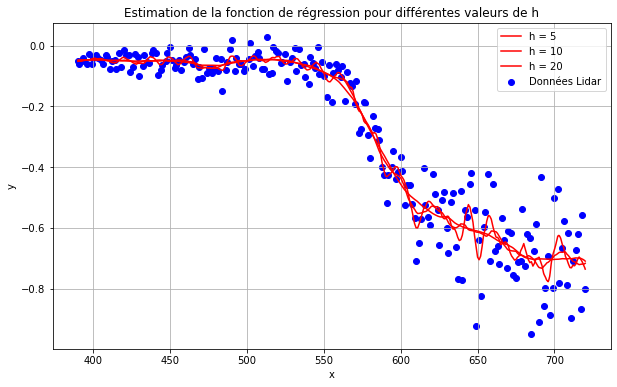

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(xech, yech, color='blue', label='Données Lidar')
for h in h_values:
    regression_values = valeurs_estimees(yech, xech, x_values, h)
    plt.plot(x_values, regression_values, label=f'h = {h}', color='red')
plt.title('Estimation de la fonction de régression pour différentes valeurs de h')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


Plus la fenêtre est grande (ici,h=20), plus l'estimations s'applatient. C'est bien normal car l'on prend plus de points et par conséquent on évite le surapprentissage.

Ensuite, on crée la fonction noyau_cv_signle qui calcule l'erreur de validation croisée leave-one-out pour une seule observation retirée et ensuite noyau_cv qui calcule l'erreur de validation croisée leave-one-out pour une valeur de h donnée. 

In [15]:
def noyau_cv_single(yech, xech, h, index):
   
    yech_copy = np.delete(yech, index)
    xech_copy = np.delete(xech, index)
    
    y_pred = reg_noyau(yech_copy, xech[index], xech_copy, h)
    
    error = np.abs(y_pred - yech[index])
    
    return error

def noyau_cv(yech, xech, h):
    
    n = len(yech)
    errors = []
    for i in range(n):
        error = noyau_cv_single(yech, xech, h, i)
        errors.append(error)
    return np.mean(errors)

# Exemple d'utilisation
h = 20  # Valeur de h donnée
erreur_cv = noyau_cv(yech, xech, h)
print("Erreur de validation croisée leave-one-out pour h =", h, ":", erreur_cv)


Erreur de validation croisée leave-one-out pour h = 20 : 0.05688495470772827


On utilise un grid search pour trouver la fenêtre optimale à prendre en fonction de l'erreur : 

In [16]:
h_values = np.linspace(1, 50, 50)  

cv_errors = []
for h in h_values:
    cv_error = noyau_cv(yech, xech, h)
    cv_errors.append(cv_error)

best_h_index = np.argmin(cv_errors)
best_h = h_values[best_h_index]
best_cv_error = cv_errors[best_h_index]

print("La meilleure valeur de h est :", best_h)
print("Erreur de validation croisée minimale pour h =", best_h, ":", best_cv_error)


La meilleure valeur de h est : 30.0
Erreur de validation croisée minimale pour h = 30.0 : 0.05623966111404624


Il semblerait que la valeur optimale soit donc 30. On l'utilise dans le graph de régression : 

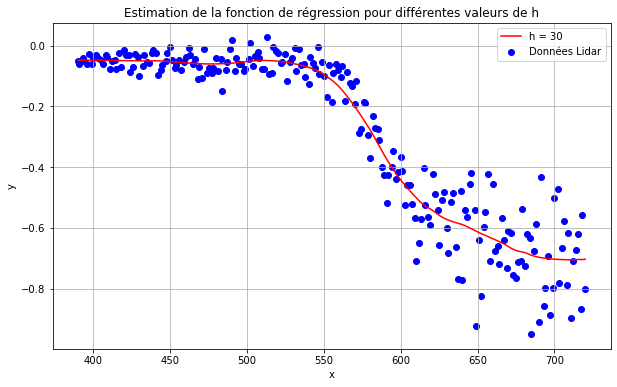

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(xech, yech, color='blue', label='Données Lidar')

regression_values = valeurs_estimees(yech, xech, x_values, 30)

plt.plot(x_values, regression_values, label=f'h = {30}', color='red')
plt.title('Estimation de la fonction de régression pour différentes valeurs de h')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Comme on peut voir il n'y a pas de surapprentissage car la courbe n'est pas trop ondulé mais la courbe n'est pas non plus uniquement le biais. La fenetre a bien été choisie car elle semble approcher bien tous les points.

Enfin on fait une estimation par Bsplines donc classique à 2 : 

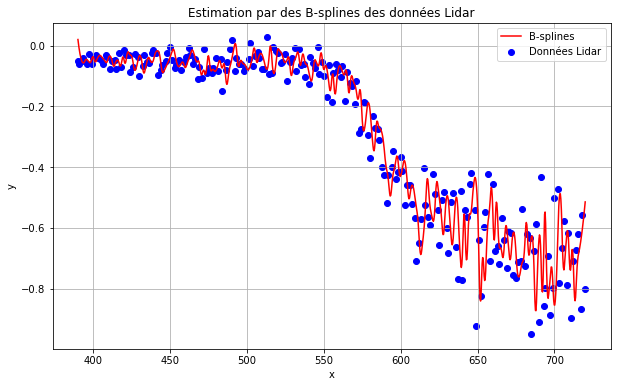

In [19]:
degree = 2 
t = np.linspace(min(xech), max(xech), len(xech) - degree + 2)
spl = BSpline(t, yech, degree)

x_values = np.linspace(min(xech), max(xech), 1000)
y_values = spl(x_values)

plt.figure(figsize=(10, 6))
plt.scatter(xech, yech, color='blue', label='Données Lidar')
plt.plot(x_values, y_values, label='B-splines', color='red')
plt.title('Estimation par des B-splines des données Lidar')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

On voit ici un surappprentissage qui pourrait être éviter en augmentant le nombre de noeuds.